# Setup

In [1]:
import sys
import os
from pathlib import Path

## Muss das wirklich als allererstes kommen?
os.environ["PYTHONHASHSEED"] = "51"

PROJECT_ROOT = Path.cwd().parents[0]        # sets project url as root url
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning


In [ ]:
# Install dependencies
#%cd {PROJECT_ROOT}
#%pip install --no-cache-dir -r requirements.txt

/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 11.0 MB/s  0:00:03 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 8.7 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... \

In [ ]:
# Imports
import torch

import torchvision.transforms.v2 as transforms
from typing import Optional
from torch.utils.data import Dataset
from PIL import Image

import wandb


from src.config import (DEVICE, NUM_WORKERS, SEED, PROJECT_ROOT, DATA_DIR, PLACES_DATASET_DIR) 

In [ ]:
# Constants
SEED = 51
NUM_WORKERS = 0
NUM_SAMPLES = 100

IMG_SIZE = 256
BATCH_SIZE = 32

TEST_FRAC = 0.1
VAL_FRAC = 0.2

In [ ]:
def set_seeds(seed: int = 51):
    """Set random seeds for reproducibility."""
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f"Seeds set to {seed}")


In [ ]:
set_seeds(SEED)

Seeds set to 51


In [ ]:
# Load W&B API key from Kaggle Secrets and make it available as env variable
if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

# Data Loading & Split

* Load as custom dataset
* Define 
* Show some images from train split

In [ ]:
class ImageDataset(Dataset):
    """Loads images from a folder with explicit start/end index control and returns a tensor in [0,1], shape (C,H,W)."""
    def __init__(
        self,
        root: str,
        start_idx: int = 0,
        end_idx: Optional[int] = None,
        transform: Optional[callable] = None,
    ):
        self.root = Path(root)
        self.transform = transform

       # deterministic ordering; include .jpg and .JPG
        files = sorted(list(self.root.glob("*.jpg")) + list(self.root.glob("*.JPG")))

        if len(files) == 0:
            raise FileNotFoundError(f"No .jpg images found in {self.root}")

        self.files = files[start_idx:end_idx]
        if len(self.files) == 0:
            raise ValueError("Selected subset is empty (check start_idx/end_idx)")

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> torch.Tensor:
        img = Image.open(self.files[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)
            
        return img  # float32, [0,1], (C,H,W)

In [ ]:
img_base_transforms = transforms.Compose([
    transforms.ToImage(),   # Scales data into [0,1]
    transforms.ToDtype(torch.float32, scale=True)
])

In [ ]:
base_data = ImageDataset(PLACES_DATASET_DIR, start_idx=0, end_idx=NUM_SAMPLES, transform=img_base_transforms)
print(base_data[0].shape, base_data[0].dtype, base_data[0].min().item(), base_data[0].max().item())

torch.Size([3, 256, 256]) torch.float32 0.0 1.0


In [ ]:
import matplotlib.pyplot as plt

def show_dataset_grid(dataset, n=8, cols=4):
    """
    Show n images from a dataset in a grid.
    Return: tensor (C,H,W) in [0,1].
    """
    rows = (n + cols - 1) // cols
    fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    ax = ax.flatten()

    # Show the first n images from the dataset.
    for idx in range(n):
        img = dataset[idx]          # (C,H,W)
        img = img.permute(1, 2, 0)  # reorders dim: (C,H,W) -> (H,W,C)
        ax[idx].imshow(img)
        ax[idx].axis("off")

    # Hide unused axes
    for j in range(n, len(ax)):
        ax[j].axis("off")

    plt.tight_layout()

    return fig, ax


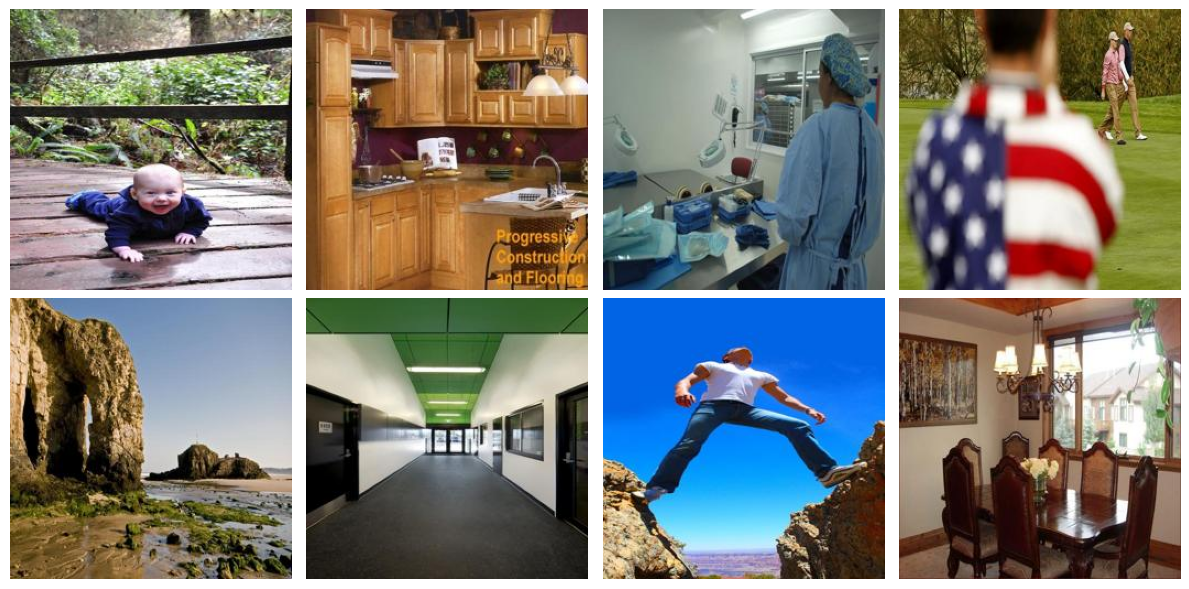

In [ ]:
fig, ax = show_dataset_grid(base_data, 8, 4)
plt.show()

In [ ]:
from torch.utils.data import Subset
from typing import Tuple


def train_test_val_split(
    dataset,
    val_frac: float = 0.1,
    test_frac: float = 0.1,
    seed: int = 51,
) -> Tuple[Subset, Subset, Subset]:

    n = len(dataset)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g).tolist()

    n_val = int(round(n * val_frac))
    n_test = int(round(n * test_frac))
    
    # ensure all samples are used
    n_train = n - n_test - n_val

    train_idx = perm[:n_train]
    val_idx   = perm[n_train:n_train + n_val]
    test_idx  = perm[n_train + n_val:]

    return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)

In [ ]:
train_base_data, val_base_data, test_base_data = train_test_val_split(
    base_data,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SEED
)

# Data Preprocessing

In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def compute_dataset_mean_std(
    dataset,
    batch_size: int = 32,
):
    """
    Compute per-channel mean and std on the train dataset that returns
    images as tensors in [0,1], shape (C,H,W).
    """
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),       ## TODO: what does it do?
    )

    channel_sum = 0.0
    channel_sq_sum = 0.0
    pixel_count = 0

    for img in tqdm(loader):
        img = img.float()               # (B,C,H,W)
        b, c, h, w = img.shape

        pixel_count += b * h * w                # total pixel count across all batches with height x width
        channel_sum += img.sum(dim=(0, 2, 3))   # sum over batch_dim, height and width -> (C,)
        channel_sq_sum += (img ** 2).sum(dim=(0, 2, 3)) # accumulate squared sum per channel

    mean = channel_sum / pixel_count
    var = channel_sq_sum / pixel_count - mean ** 2
    std = torch.sqrt(var.clamp(min=1e-12))          # 1e-12 ensures numerical stability

    return mean.tolist(), std.tolist()


In [ ]:
# Calculates mean and standard deviation of the rgb train data
# for different dataset (or change in train data) recalculate mean and standard deviation
mean, std = compute_dataset_mean_std(base_data, batch_size=BATCH_SIZE)
print(mean, std)

100%|██████████| 4/4 [00:00<00:00, 32.57it/s]

[0.43773841857910156, 0.42314186692237854, 0.39335986971855164] [0.2770063877105713, 0.2716153562068939, 0.2899497151374817]


In [ ]:
class TransformDataset(Dataset):
    def __init__(self, base: Dataset, transform):
        self.base = base
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x = self.base[idx]
        return self.transform(x)

In [ ]:
normalize_transforms = transforms.Compose([
    transforms.Normalize(mean, std)     # uncomment for different dataset (or change in train data)
])

In [ ]:
train_norm = TransformDataset(train_base_data, normalize_transforms)
val_norm   = TransformDataset(val_base_data, normalize_transforms)
test_norm  = TransformDataset(test_base_data, normalize_transforms)

# Mask generation

Choose a random top-left corner (y, x) such that:
y + h_mask ≤ H
x + w_mask ≤ W

Binary mask image
* Mask has shape (H, W) (or (1, H, W) in tensor form)
* All pixels are 1 (visible)
* Pixels inside the rectangle are set to 0 (missing)

Apply mask to image
* Masked image = original image × mask
* Missing region is zeroed out

Option A — Same mask position per image (recommended)
Each image gets its own random mask. The position is:
* random
* but deterministic per image (e.g. based on index or filename)
--> This means:
* Image A always has the same masked region
* Image B has a different (but fixed) region

“Each image is assigned a fixed rectangular mask sampled once, ensuring reproducibility while still varying the occluded region across images.”

**Why rectangular masks?**
They remove contiguous regions and require the model to exploit spatial context, unlike random pixel dropout which resembles denoising.

**Why include the mask explicitly?**
The mask tells the model which pixels are missing and should be reconstructed, avoiding ambiguity.

**How to secure same mask for same image each epoch**
Analogy (this usually clicks immediately)

Think of a function:

mask = f(image_id, fixed_seed)


You don’t “store” the output of f.

You just call f again.

Same input → same output

But the variable holding the output is temporary

This is exactly what you’re doing with mask generation.

What guarantees “same mask every epoch”?

One thing only:

🔒 Deterministic mask generation

For example (conceptually):

seed = global_seed + image_id

mask position derived from that seed

As long as:

the same image_id is used

the same seed logic is used

👉 the mask is identical every time, across epochs, runs, machines.

“For each image, the mask position is generated deterministically using a fixed random seed combined with the dataset index, ensuring that every image sees the same masked region across epochs.”

In [ ]:
import random

class InpaintingDataset(Dataset):
    """
    Wrapper dataset: returns (x_in, y, mask), where
      y     = original image tensor (C,H,W)
      mask  = binary mask tensor (1,H,W), 1=visible, 0=missing
      x_in  = either masked image (C,H,W) OR concat(masked image, mask) (C+1,H,W)

    Deterministic masks: seed derived from (global_seed + idx) OR from filename hash (more robust).
    """
    def __init__(
        self,
        base: Dataset,
        h_mask: int,
        w_mask: int,
        seed: int = 51,
        # fixed_mask_per_image: bool = True,        ## later extension with random masks for.each img
    ):
        self.base = base
        self.h_mask = h_mask
        self.w_mask = w_mask
        self.seed = seed
        #self.fixed = fixed_mask_per_image          ## later extension with random masks for.each img

    def __len__(self):
        return len(self.base)
    

    def _rng_for(self, idx: int) -> random.Random:
        ## later extension with random masks for.each img
        #if not self.fixed:
        #    return random.Random()  # nondeterministic
        return random.Random(self.seed + idx)
        

    def __getitem__(self, idx: int):
        # randomly generate the mask start_point (x,y) which is inside IMG_SIZExIMG_SIZE
        # and make sure that y + h_mask ≤ H and x + w_mask ≤ W
        # create mask with IMG_SIZExIMG_SIZE where all 1 apart from y + h_mask and x + w_mask ≤ W are 0
        # apply mask on img by multiplying elementwise
        # return img_masked, mask, img
        img = self.base[idx]                             # (C,H,W) tensor
        
        C, H, W = img.shape
        # ensures that mask is not bigger than the image
        h = min(self.h_mask, H)
        w = min(self.w_mask, W)

        rng = self._rng_for(idx)

        # pick top-left so rectangle stays inside image
        top = rng.randint(0, H - h)
        left = rng.randint(0, W - w)

        # create mask: 1 everywhere, 0 inside rectangle
        mask = torch.ones((1, H, W), dtype=torch.float32)
        mask[:, top:top + h, left:left + w] = 0.0

        # apply mask (broadcast over channels)
        masked_img = img * mask

        # includes the mask as extra channel
        x_in = torch.cat([masked_img, mask], dim=0)  # (C+1,H,W)

        return x_in, img, mask

In [ ]:
H_MASK = 70
W_MASK = 90

train_data = InpaintingDataset(train_norm, H_MASK, W_MASK, SEED)
val_data   = InpaintingDataset(val_norm, H_MASK, W_MASK, SEED)
test_data  = InpaintingDataset(test_norm, H_MASK, W_MASK, SEED)

In [ ]:
import matplotlib.pyplot as plt
import torch

def show_inpainting_example(dataset, idx=0):
    """
    Show a single inpainting example:
    Target | Mask | Masked input
    """
    x_in, y, mask = dataset[idx]

    target = y.detach().cpu().clamp(0, 1).permute(1, 2, 0)
    m = mask[0].detach().cpu()
    masked = x_in[:3].detach().cpu().clamp(0, 1).permute(1, 2, 0)

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    ax[0].imshow(target)
    ax[0].set_title("Target (ground truth)")
    ax[0].axis("off")

    ax[1].imshow(m, cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("Mask")
    ax[1].axis("off")

    ax[2].imshow(masked)
    ax[2].set_title("Masked input")
    ax[2].axis("off")

    plt.tight_layout()

    return fig, ax


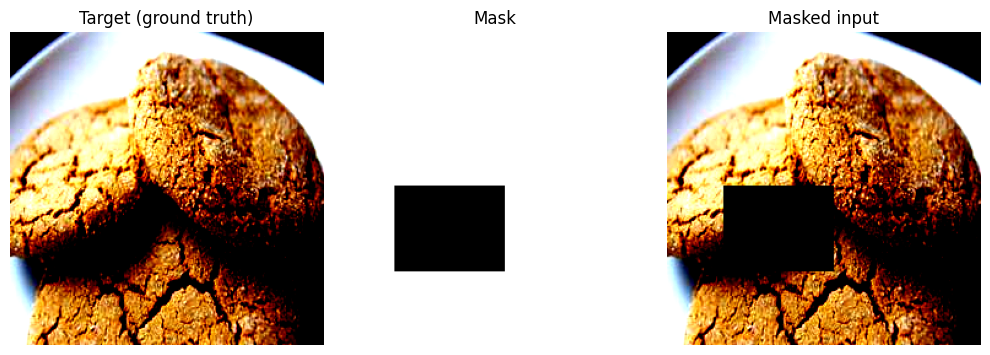

In [ ]:
show_inpainting_example(train_data, idx=10)
plt.show()

In [ ]:
import math
import matplotlib.pyplot as plt
import torch
from typing import Sequence, Optional

def show_img_grid(
    tensors: Sequence[torch.Tensor],
    titles: Optional[Sequence[str]] = None,
    cols: int = 3,
    cmap_mask: str = "gray",
):
    """
    Show an arbitrary number of tensors in a grid with fixed number of columns.

    tensors:
      - list of tensors
      - RGB: (3,H,W)
      - Mask: (1,H,W) or (H,W)

    titles:
      - optional list of titles (same length as tensors)

    cols:
      - number of images per row (default: 3)
    """
    n = len(tensors)
    rows = math.ceil(n / cols)

    fig, ax = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    ax = ax.flatten() if n > 1 else [ax]

    for i, tensor in enumerate(tensors):
        x = tensor.detach().cpu()

        # RGB image
        if x.dim() == 3 and x.size(0) == 3:
            x = x.clamp(0, 1).permute(1, 2, 0)
            ax[i].imshow(x)

        # Mask: (1,H,W)
        elif x.dim() == 3 and x.size(0) == 1:
            ax[i].imshow(x[0], cmap=cmap_mask, vmin=0, vmax=1)

        # Mask: (H,W)
        elif x.dim() == 2:
            ax[i].imshow(x, cmap=cmap_mask, vmin=0, vmax=1)

        else:
            raise ValueError(f"Unsupported tensor shape: {tuple(x.shape)}")

        ax[i].axis("off")
        if titles is not None:
            ax[i].set_title(titles[i])

    # Hide unused axes
    for j in range(i + 1, len(ax)):
        ax[j].axis("off")

    plt.tight_layout()
    return fig, ax


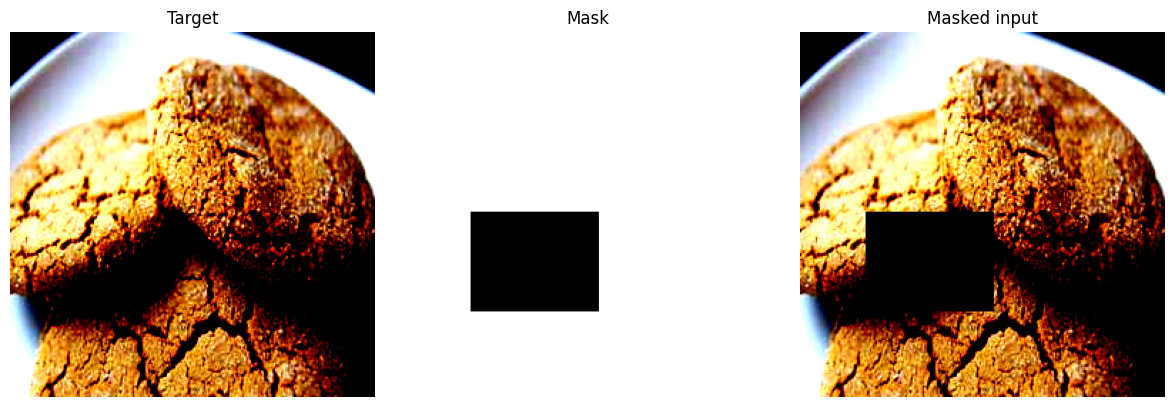

In [ ]:
x_in, img, mask = train_data[10]

show_img_grid(
    tensors=[img, mask, x_in[:3]],
    titles=["Target", "Mask", "Masked input"]
)
plt.show()

In [ ]:
from torch.utils.data import DataLoader

## TODO: should I try to make the train loader deterministic?
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

TypeError: DataLoader.__init__() got an unexpected keyword argument 'transforms'

# Baseline

In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def diffusion_inpaint(
    masked: torch.Tensor,   # (B, C, H, W) masked image (missing area typically 0)
    mask: torch.Tensor,     # (B, 1, H, W) 1=known, 0=missing
    num_iters: int = 200,   # more iterations = smoother fill, but more blur
) -> torch.Tensor:
  """
  Simple diffusion / neighbor-averaging inpainting baseline.

  Updates only missing pixels each iteration:
    x_missing <- avg_4_neighbors(x)

  Returns:
    filled image (B, C, H, W)
  """
  B, C, H, W = masked.shape
  device = masked.device
  dtype = masked.dtype

  known = mask  # (B,1,H,W)
  missing = 1.0 - known

  # create a kernel with +1 for neighboring pixel
  # 4-neighbor averaging kernel applied for each channel
  kernel = torch.tensor(
      [[0.0, 1.0, 0.0],
        [1.0, 0.0, 1.0],
        [0.0, 1.0, 0.0]],
      device=device, dtype=dtype
  ).view(1, 1, 3, 3)

  # apply the kernel on each channel
  kernel = kernel.repeat(C, 1, 1, 1)    # (C,1,3,3)

  # make a copy of the input image to not overwrite permanently
  img_inpainted = masked.clone()

  # in each iteration apply the kernel via Conv2d on the whole image and fill current pixel with average value
  # of neighbours
  for _ in range(num_iters):
    neigh_sum = F.conv2d(img_inpainted, kernel, padding=1, groups=C)  # sum values of all neighbour 

    # Average over number of neighbours
    # Each pixel has up to 4 neighbors; near borders fewer -> normalize by neighbor count
    ones = torch.ones((B, 1, H, W), device=device, dtype=dtype)
    neigh_count = F.conv2d(ones, kernel[:1], padding=1)  # (B,1,H,W)
    neigh_avg = neigh_sum / (neigh_count + 1e-8)         # (B,C,H,W) via broadcast

    # Only update missing region; rest of the image stays unchanged
    img_inpainted = img_inpainted * known + neigh_avg * missing

  return img_inpainted


In [ ]:
x_in, img, mask = train_data[10]
masked_img = x_in[:3].unsqueeze(0)       # remove channel with mask

pred = diffusion_inpaint(masked_img, mask, num_iters=250)
pred = pred.squeeze(0)

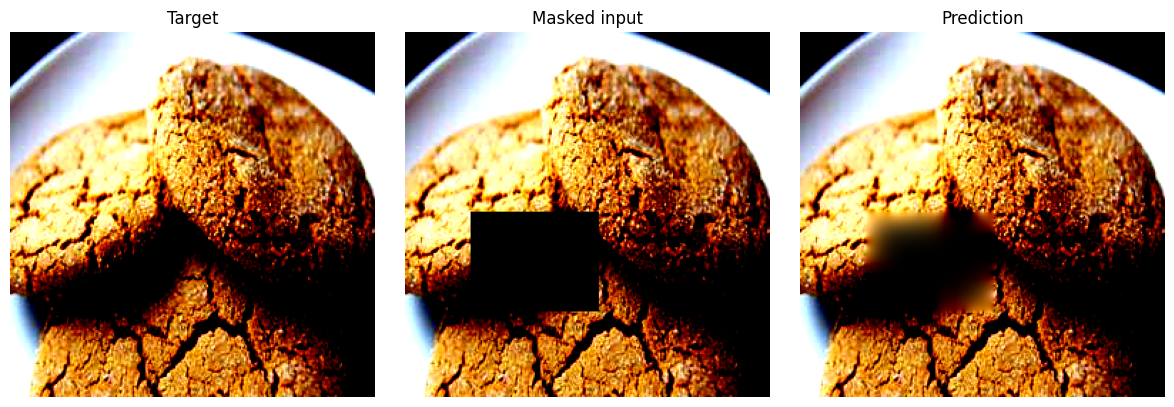

In [ ]:
show_img_grid(
    tensors=[img, x_in[:3], pred],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

In [ ]:
x_in, img, mask = train_data[20]
masked_img = x_in[:3].unsqueeze(0)       # remove channel with mask

pred_diffusion = diffusion_inpaint(masked_img, mask, num_iters=50)
pred_diffusion = pred_diffusion.squeeze(0)

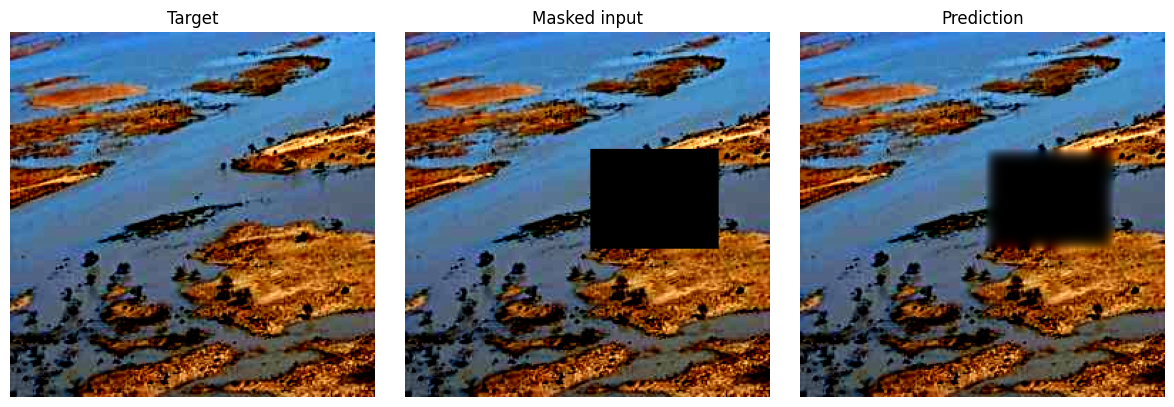

In [ ]:
show_img_grid(
    tensors=[img, x_in[:3], pred_diffusion],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def inpaint_known_neighbors_only(
    masked: torch.Tensor,  # (B,C,H,W) missing pixels can be 0
    mask: torch.Tensor,    # (B,1,H,W) 1=known, 0=missing
    max_iters: int = 500,
    tol: float = 0.0,      # set >0 for early stopping (optional)
) -> torch.Tensor:
    """
    Fill missing pixels using ONLY neighbors that are currently known/filled.
    Vectorized "wavefront" inpainting: missing pixels fill from boundary inward.

    Returns:
      x_filled: (B,C,H,W)
    """
    assert masked.dim() == 4
    assert mask.dim() == 4 and mask.size(1) == 1
    B, C, H, W = masked.shape
    device, dtype = masked.device, masked.dtype

    # 4-neighbor kernel
    k = torch.tensor([[0., 1., 0.],
                      [1., 0., 1.],
                      [0., 1., 0.]], device=device, dtype=dtype).view(1,1,3,3)

    # per-channel grouped kernel
    kC = k.repeat(C, 1, 1, 1)  # (C,1,3,3)

    x = masked.clone()
    K = mask.clone()  # (B,1,H,W) current knownness (starts with original known pixels)

    for _ in range(max_iters):
        x_prev = x

        # Sum ONLY from currently known pixels:
        # (x*K) broadcasts K across channels => (B,C,H,W)
        neigh_sum = F.conv2d(x * K, kC, padding=1, groups=C)      # (B,C,H,W)
        neigh_cnt = F.conv2d(K, k, padding=1)                     # (B,1,H,W), counts known neighbors

        # Pixels we are allowed to fill this iteration:
        fillable = (K == 0) & (neigh_cnt > 0)                     # (B,1,H,W)

        # Compute average of known neighbors (avoid division by 0 via masking)
        neigh_avg = neigh_sum / (neigh_cnt + 1e-8)                # (B,C,H,W) via broadcast

        # Update ONLY fillable pixels (broadcast fillable to channels)
        fillableC = fillable.expand(-1, C, -1, -1)                # (B,C,H,W)
        x = torch.where(fillableC, neigh_avg, x)

        # Mark newly filled pixels as known for next iteration
        K = torch.where(fillable, torch.ones_like(K), K)

        # stop if everything filled
        if (K == 0).sum().item() == 0:
            break

        # optional early stop based on small changes
        if tol > 0.0:
            diff = (x - x_prev).abs()
            # consider only pixels that were updated this iter
            change = diff * fillableC
            if change.max().item() < tol:
                break

    return x


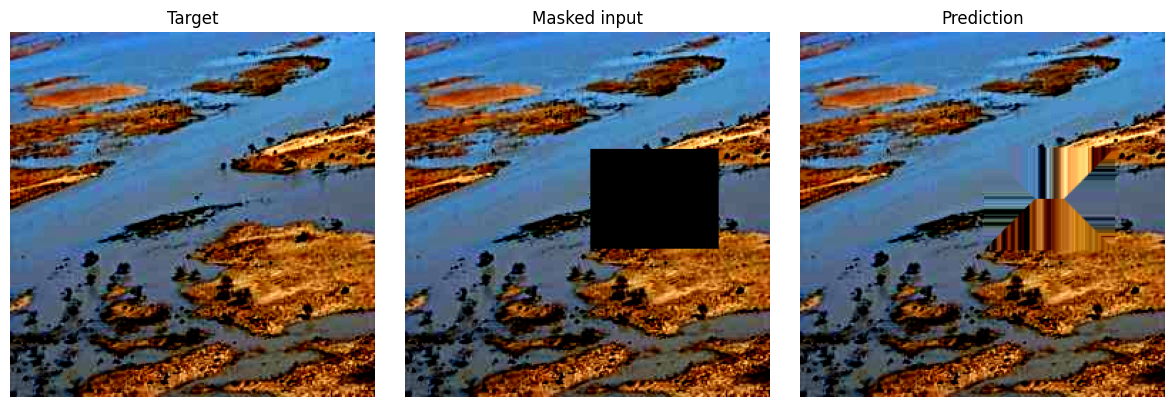

In [ ]:
x_in, img, mask = train_data[20]
masked_img = x_in[:3].unsqueeze(0)       # remove channel with mask

pred_only_neigh = inpaint_known_neighbors_only(masked_img, mask.unsqueeze(0), max_iters=100)
pred_only_neigh = pred_only_neigh.squeeze(0)

show_img_grid(
    tensors=[img, x_in[:3], pred_only_neigh],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

In [ ]:
@torch.no_grad()
def diffusion_inpaint_weighted_knownness(
    masked: torch.Tensor,  # (B,C,H,W)
    mask: torch.Tensor,    # (B,1,H,W) 1=known, 0=missing
    num_iters: int = 200,
    alpha: float = 0.1,    # weight for missing neighbors (0 -> known-only; 1 -> standard diffusion)
) -> torch.Tensor:
    """
    Weighted diffusion inpainting:
    neighbors are averaged with weights depending on knownness:
      w = 1 for known pixels, w = alpha for missing pixels.

    alpha=1.0 -> standard diffusion
    alpha=0.0 -> known-neighbors-only averaging (but without wavefront logic)
    """
    assert masked.dim() == 4
    assert mask.dim() == 4 and mask.size(1) == 1
    B, C, H, W = masked.shape
    device, dtype = masked.device, masked.dtype

    k = torch.tensor([[0., 1., 0.],
                      [1., 0., 1.],
                      [0., 1., 0.]], device=device, dtype=dtype).view(1,1,3,3)
    kC = k.repeat(C, 1, 1, 1)

    known = mask
    missing = 1.0 - known

    # weights per pixel (known=1, missing=alpha)
    Wpix = known + alpha * missing   # (B,1,H,W)

    x = masked.clone()

    for _ in range(num_iters):
        # weighted neighbor sum
        neigh_sum = F.conv2d(x * Wpix, kC, padding=1, groups=C)   # (B,C,H,W)
        # weighted neighbor count
        neigh_wsum = F.conv2d(Wpix, k, padding=1)                # (B,1,H,W)

        neigh_avg = neigh_sum / (neigh_wsum + 1e-8)

        # keep known pixels fixed, update missing pixels
        x = x * known + neigh_avg * missing

    return x


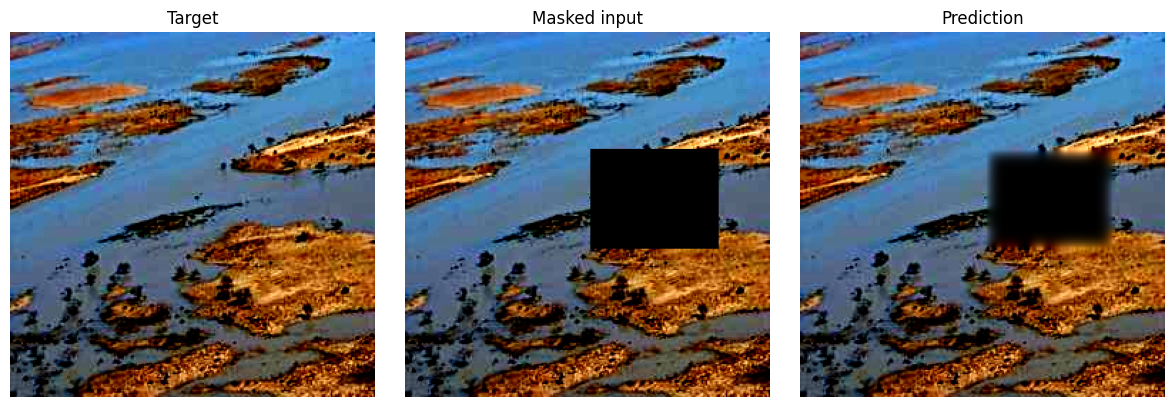

In [ ]:
pred_weigthed = diffusion_inpaint_weighted_knownness(masked_img, mask.unsqueeze(0), num_iters=50)
pred_weigthed = pred_weigthed.squeeze(0)

show_img_grid(
    tensors=[img, x_in[:3], pred_weigthed],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

## Evaluation

The big rule: evaluate on the masked region, otherwise the “easy” known pixels dominate and hide differences.

### MAE
Masked L1 (MAE) and/or Masked L2 (MSE):
* Masked L1 (recommended): sharper, less sensitive to outliers than MSE.
* Masked MSE: classic, but can encourage over-smoothing.


Let $ M \in {0,1}^{H \times W}$ be the binary mask, where  
$( M_{ij} = 1)$ indicates known pixels and $( M_{ij} = 0)$ indicates missing pixels.  
The missing-pixel indicator is $(1 - M)$.

For an RGB image, the masked mean absolute error (MAE) is defined as:
$$
\mathrm{MAE}_{\text{miss}} =
\frac{\sum_{i,j,c} \left| \hat{y}_{i,j,c} - y_{i,j,c} \right| \cdot (1 - M_{i,j})}
     {\sum_{i,j} (1 - M_{i,j})}
$$

where $\hat{y}$ is the reconstructed image and $y$ is the ground truth.



### PSNR: 
*!!TODO:* very common in image reconstruction papers - look for it


For images scaled to $[0,1]$, the maximum possible pixel value is $\mathrm{MAX} = 1$.
The masked mean squared error (MSE) is defined analogously to the masked MAE.

The peak signal-to-noise ratio (PSNR) on the missing region is given by:

$$
\mathrm{PSNR}_{\text{miss}} =
10 \log_{10}\left(
\frac{\mathrm{MAX}^2}{\mathrm{MSE}_{\text{miss}} + \varepsilon}
\right)
=
10 \log_{10}\left(
\frac{1}{\mathrm{MSE}_{\text{miss}} + \varepsilon}
\right)
$$

where $\varepsilon$ is a small constant added for numerical stability.
Interpretation: higher is better. (Diffusion baseline usually gives low PSNR on large holes.)


In [ ]:
def loss_mae_miss(predictor_fn, batch, device) -> torch.Tensor:
    """
    Masked MAE over the missing region (where mask==0).

    Args:
        y_hat: (B,C,H,W) predicted image in [0,1]
        y:     (B,C,H,W) ground truth image in [0,1]
        mask:  (B,1,H,W) 1=known, 0=missing
        eps:   numerical stability

    Returns: 
        num   = sum |y_hat - y| over missing pixels and channels
        denom = number of missing scalar values (missing pixels × channels)
    """
    x_in, y, mask = batch
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = predictor_fn(x_in, mask)

    missing = 1.0 - mask
    abs_err = (y_hat - y).abs() * missing       # absolute error over missing regions

    num = abs_err.sum()                         
    denom = missing.sum() * y.shape[1]          # calculates mean absolute error over all missing pixels, 
                                                # aggregated across the entire batch and all channels.
    return num.detach(), denom.detach()


In [ ]:
@torch.no_grad()
def evaluate_mae_miss(val_loader, predictor_fn, device, eps=1e-8):
    # model.eval()
    total_num = 0.0
    total_denom = 0.0

    for batch in val_loader:
        num, denom = loss_mae_miss(predictor_fn, batch, device)
        total_num += num.item()
        total_denom += denom.item()               # pixels × channels

    mae = total_num / (total_denom + eps)
    return mae
    #print(f"valid MAE_miss (pixel-weighted): {mae:.4f}")

NameError: name 'torch' is not defined

In [ ]:
def diffusion_predictor(x_in, mask):
    masked_rgb = x_in[:, :3]  # (B,3,H,W)
    return diffusion_inpaint(masked_rgb, mask, num_iters=200)


val_mae = evaluate_mae_miss(val_loader, diffusion_predictor, device=DEVICE)
print("val MAE_miss (diffusion):", val_mae)

In [ ]:
def loss_mse_miss(predictor_fn, batch, device) -> torch.Tensor:
    """
    Masked PSNR computed from masked MSE over the missing region (where mask==0).

    Args:
        y_hat: (B,C,H,W) predicted image in [0,1]
        y:     (B,C,H,W) ground truth image in [0,1]
        mask:  (B,1,H,W) 1=known, 0=missing
        eps:   numerical stability

    Returns:
        scalar tensor: PSNR over missing region
    """
    x_in, y, mask = batch
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = predictor_fn(x_in, mask)

    missing = 1.0 - mask
    sq_err = (y_hat - y) ** 2  # (B,C,H,W)

    num = sq_err.sum()
    denom = missing.sum() * y.shape[1]
    
    return num.detach(), denom.detach()

In [ ]:
@torch.no_grad()
def evaluate_psnr_miss(val_loader, predictor_fn, device, eps=1e-8, max_val=1.0):
    total_num = 0.0
    total_denom = 0.0

    for batch in val_loader:
        
        num, denom = loss_mse_miss(predictor_fn, batch, device)
        total_num += num.item()
        total_denom += denom.item()

    mse = total_num / (total_denom + eps)
    psnr = 10.0 * torch.log10(torch.tensor((max_val ** 2) / (mse + eps))).item()      # max_val: MAX pixel value (1.0 if images in [0,1])
    return psnr  

In [ ]:
def diffusion_predictor(x_in, mask):
    masked_rgb = x_in[:, :3]  # (B,3,H,W)
    return diffusion_inpaint(masked_rgb, mask, num_iters=200)


val_mae = evaluate_psnr_miss(val_loader, diffusion_predictor, device=DEVICE)
print("val MAE_miss (diffusion):", val_mae)

##### !!TODO Currently Option A is implemented
Two equivalent evaluation protocols: There are two mathematically valid ways to evaluate over the dataset.

**Option A — Global (pixel-weighted) average (what your code naturally supports)**
You accumulate:
* total error over all batches
* total number of missing pixels

This gives: -> Every missing pixel contributes equally, regardless of which image it comes from.
This is often preferred in reconstruction tasks.

Key characteristics
* Larger holes contribute more
* Images with many missing pixels matter more
* Stable and statistically efficient

**Option B — Per-image average, then dataset mean**

You compute: 
* MAE_miss per image
* then average across images

This gives: -> Every image contributes equally, regardless of hole size.

# Models

# Evaluation Protocol

# Training

# Evaluation